# 05 - ML Comparison

Lag, rolling-window, and calendar features, fed into XGBoost, evaluated on the **same expanding-window origins** as notebook 04's SARIMA/Holt-Winters backtest (`MIN_TRAIN=42`, `MAX_HORIZON=3`) so the two are directly comparable in notebook 06. A separate XGBoost model is trained per horizon (direct forecasting, not recursive) and refit at every origin, mirroring how SARIMA was refit at every origin — same information available to both.

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = Path("../images")

conn = sqlite3.connect(PROCESSED_DIR / "pharma_sales.db")
categories = pd.read_sql("SELECT * FROM dim_category", conn)
CODE_TO_NAME = dict(zip(categories["category_code"], categories["category_name"]))
codes = sorted(CODE_TO_NAME)

MIN_TRAIN = 42
MAX_HORIZON = 3

## Load monthly data (partial October 2019 excluded, as in notebooks 03-04)

In [2]:
monthly = pd.read_sql(
    "SELECT sale_date, category_code, units_sold FROM fact_sales WHERE granularity = 'monthly'",
    conn, parse_dates=["sale_date"]
)
monthly = monthly[monthly["sale_date"] <= "2019-09-30"].sort_values("sale_date")

def get_series(code):
    return monthly[monthly["category_code"] == code].set_index("sale_date")["units_sold"].asfreq("ME")

series = {code: get_series(code) for code in codes}
len(series["N02BE"])

69

## Feature engineering

Lags at 1, 2, 3, 6, and 12 months; rolling mean/std over 3, 6, and 12 months (computed on `shift(1)` so the current month's own value never leaks into its own features); calendar signal via month sine/cosine (avoids the false distance between month 12 and month 1 that a raw integer would create) and quarter. Targets are built directly rather than recursively: `target_h1` is next month's value, `target_h3` is the value 3 months ahead, both known only in hindsight and therefore excluded from the feature set itself.

In [3]:
def build_features(s):
    df = pd.DataFrame({"y": s})
    for lag in [1, 2, 3, 6, 12]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    for window in [3, 6, 12]:
        df[f"roll_mean_{window}"] = df["y"].shift(1).rolling(window).mean()
        df[f"roll_std_{window}"] = df["y"].shift(1).rolling(window).std()
    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)
    df["quarter"] = df.index.quarter
    df["target_h1"] = df["y"].shift(-1)
    df["target_h3"] = df["y"].shift(-3)
    return df

FEATURE_COLS = [
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "roll_mean_3", "roll_mean_6", "roll_mean_12",
    "roll_std_3", "roll_std_6", "roll_std_12",
    "month_sin", "month_cos", "quarter",
]

features = {code: build_features(series[code]) for code in codes}
features["N02BE"].tail()

,y,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12,month_sin,month_cos,quarter,target_h1,target_h3
sale_date,,,,,,,,,,,,,,,,,
2019-05-31,703.562,647.650,941.050,1001.212,995.150,644.648,863.304000,189.168846,1076.604000,339.005722,940.778333,310.506605,5.000000e-01,-8.660254e-01,2,610.00,518.10
2019-06-30,610.000,703.562,647.650,941.050,1213.950,584.343,764.087333,155.783109,1028.006000,372.284671,945.687833,305.829282,1.224647e-16,-1.000000e+00,2,649.80,984.48
2019-07-31,649.800,610.000,703.562,647.650,1660.612,679.350,653.737333,47.077104,927.347667,393.024332,947.825917,303.151390,-5.000000e-01,-8.660254e-01,3,518.10,NaN
2019-08-31,518.100,649.800,610.000,703.562,1001.212,733.838,654.454000,46.954305,758.879000,168.170510,945.363417,305.640279,-8.660254e-01,-5.000000e-01,3,984.48,NaN
2019-09-30,984.480,518.100,649.800,610.000,941.050,1058.262,592.633333,67.545713,678.360333,142.657851,927.385250,324.948700,-1.000000e+00,-1.836970e-16,3,NaN,NaN


## Walk-forward backtest

At each origin, features/targets from rows strictly before the origin are used to train two fresh XGBoost regressors (one for `target_h1`, one for `target_h3`), then a single prediction is made from the feature row at the origin's last known month. `n_estimators` and `max_depth` are kept small deliberately — training sets here are tiny (well under 100 rows once the 12-month lag window and per-horizon shift eat into it), and a deep/large model would just memorize noise.

**Leakage trap avoided here:** the training cutoff is `origin - horizon`, not `origin`. The naive `df.iloc[:origin]` looks right (it matches how `train = s.iloc[:origin]` was written for SARIMA in notebook 04) but is wrong for this feature/target framing — the row at position `origin - 1` has `target_h1` equal to the actual value at `origin`, which is exactly what's being forecast. Training on that row and then predicting from that same row is close to handing the model the answer. First draft of this notebook did exactly that and got a laughably good ~1% MAPE; the fix below (`cutoff = origin - horizon`) drops any training row whose target reaches into the forecast horizon.

In [4]:
def fit_predict(df, origin, horizon, target_col):
    cutoff = origin - horizon
    train = df.iloc[:cutoff].dropna(subset=FEATURE_COLS + [target_col])
    model = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
    )
    model.fit(train[FEATURE_COLS], train[target_col])
    pred_row = df.iloc[[origin - 1]][FEATURE_COLS]
    return model.predict(pred_row)[0], model

ml_records = []
for code in codes:
    s, df = series[code], features[code]
    for origin in range(MIN_TRAIN, len(s) - MAX_HORIZON):
        actual = s.iloc[origin:origin + MAX_HORIZON]
        origin_date = s.index[origin - 1]

        pred_h1, _ = fit_predict(df, origin, 1, "target_h1")
        pred_h3, _ = fit_predict(df, origin, 3, "target_h3")

        ml_records.append({"category_code": code, "model": "xgboost", "origin_date": origin_date,
                            "horizon": 1, "actual": actual.iloc[0], "predicted": pred_h1})
        ml_records.append({"category_code": code, "model": "xgboost", "origin_date": origin_date,
                            "horizon": 3, "actual": actual.iloc[2], "predicted": pred_h3})

ml_backtest = pd.DataFrame(ml_records)
ml_backtest.to_csv(PROCESSED_DIR / "backtest_results_ml.csv", index=False)
ml_backtest.shape

(384, 6)

## XGBoost backtest error summary, and a preview against notebook 04's SARIMA result

The full model-vs-model comparison (all 6 models, all categories) is assembled formally in notebook 06; this is a quick sanity check that XGBoost is at least in the right ballpark before moving on.

In [5]:
def summarize_errors(df):
    err = df["actual"] - df["predicted"]
    mae = err.abs().mean()
    rmse = np.sqrt((err ** 2).mean())
    mape = (err.abs() / df["actual"].abs()).mean() * 100
    return pd.Series({"MAE": mae, "RMSE": rmse, "MAPE": mape})

xgb_summary = ml_backtest.groupby("horizon").apply(summarize_errors, include_groups=False).round(2)

ts_backtest = pd.read_csv(PROCESSED_DIR / "backtest_results_ts_models.csv")
sarima_summary = (
    ts_backtest[ts_backtest["model"] == "sarima"]
    .groupby("horizon").apply(summarize_errors, include_groups=False).round(2)
)

pd.concat({"xgboost": xgb_summary, "sarima": sarima_summary}, names=["model"])

MAE   RMSE   MAPE
model   horizon                     
xgboost 1        40.72  73.84  21.45
        3        51.48  89.17  26.11
sarima  1        34.99  70.67  18.40
        3        42.07  86.16  19.41

In [6]:
xgb_per_category = (
    ml_backtest[ml_backtest["horizon"] == 1]
    .groupby("category_code").apply(summarize_errors, include_groups=False)["MAPE"]
)
sarima_per_category = (
    ts_backtest[(ts_backtest["model"] == "sarima") & (ts_backtest["horizon"] == 1)]
    .groupby("category_code").apply(summarize_errors, include_groups=False)["MAPE"]
)
pd.DataFrame({"xgboost_mape": xgb_per_category, "sarima_mape": sarima_per_category}).round(2)

,xgboost_mape,sarima_mape
category_code,,
M01AB,9.95,8.82
M01AE,13.45,11.44
N02BA,19.64,15.16
N02BE,16.93,12.47
N05B,12.93,11.37
N05C,41.32,31.72
R03,30.04,29.95
R06,27.30,26.28


**Finding:** with the leak fixed, SARIMA beats XGBoost on 7 of 8 categories at the 1-month horizon (overall MAPE 18.4% vs 21.5%), and the gap widens at 3 months (19.4% vs 26.1%). XGBoost only edges ahead on R03 by a negligible margin (29.95 vs 30.04), effectively a tie. This matches the expectation set in notebook 03: with 69 monthly points per category, there isn't enough data for a generic gradient-boosted tree to out-learn a model (SARIMA) that has the seasonal/autoregressive structure built into its assumptions rather than needing to discover it from scratch. The honest conclusion for notebook 06: SARIMA (or Holt-Winters, per notebook 04's per-category result) should drive the production forecasts, not XGBoost — XGBoost is included here for a documented, fair comparison, not because it wins.

## Feature importance

Fit once on all available data per category (1-month-ahead target) to see which engineered features the model actually leans on, for the two highest-volume categories.

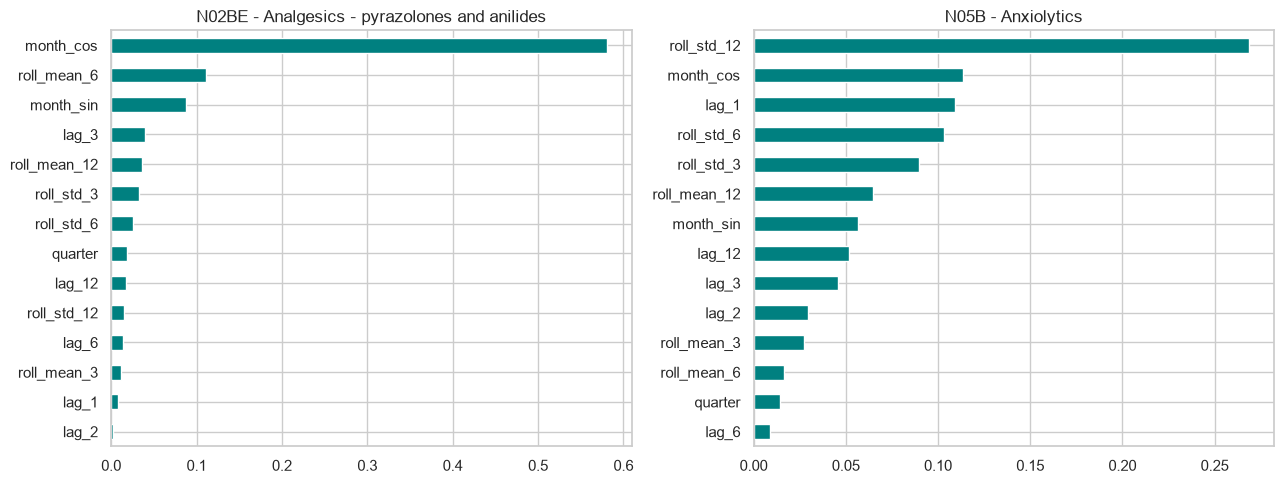

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, code in zip(axes, ["N02BE", "N05B"]):
    df = features[code].dropna(subset=FEATURE_COLS + ["target_h1"])
    model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model.fit(df[FEATURE_COLS], df["target_h1"])
    importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    importance.plot(kind="barh", ax=ax, color="teal")
    ax.set_title(f"{code} - {CODE_TO_NAME[code]}")

fig.tight_layout()
fig.savefig(IMAGES_DIR / "xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** for N02BE, `month_cos` alone accounts for more than half the model's total importance (0.58) — the model has essentially learned "what calendar month is it" as its dominant signal, consistent with the strong, regular seasonality found in notebooks 02-03. N05B leans instead on `roll_std_12` (12-month rolling volatility) as its top feature, suggesting its predictability comes more from how erratic the recent year has been than from a fixed calendar pattern — consistent with N05B's more irregular seasonal boxplot in notebook 02 (spread out, with several distinct spikes rather than a single clean peak month).

## Final forecasts: next 1 and 3 months

Refit on all available data (through September 2019) and predict forward, for the notebook 06 comparison table alongside the SARIMA forecasts from notebook 04.

In [8]:
final_ml_forecasts = []
for code in codes:
    df = features[code]
    last_row = df.iloc[[-1]][FEATURE_COLS]

    for h, target_col in [(1, "target_h1"), (3, "target_h3")]:
        train = df.dropna(subset=FEATURE_COLS + [target_col])
        model = XGBRegressor(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
        )
        model.fit(train[FEATURE_COLS], train[target_col])
        forecast = model.predict(last_row)[0]
        forecast_date = df.index[-1] + pd.DateOffset(months=h)
        final_ml_forecasts.append({
            "category_code": code, "category_name": CODE_TO_NAME[code],
            "horizon": h, "forecast_date": forecast_date, "forecast": forecast,
        })

final_ml_forecasts_df = pd.DataFrame(final_ml_forecasts)
final_ml_forecasts_df.to_csv(PROCESSED_DIR / "final_xgboost_forecasts.csv", index=False)
final_ml_forecasts_df

,category_code,category_name,horizon,forecast_date,forecast
0,M01AB,Anti-inflammatory (acetic acid derivatives),1,2019-10-30,189.867325
1,M01AB,Anti-inflammatory (acetic acid derivatives),3,2019-12-30,162.114120
2,M01AE,Anti-inflammatory (propionic acid derivatives),1,2019-10-30,105.931313
3,M01AE,Anti-inflammatory (propionic acid derivatives),3,2019-12-30,118.096977
4,N02BA,Analgesics - salicylic acid derivatives,1,2019-10-30,98.814522
5,N02BA,Analgesics - salicylic acid derivatives,3,2019-12-30,101.233101
6,N02BE,Analgesics - pyrazolones and anilides,1,2019-10-30,1063.623901
7,N02BE,Analgesics - pyrazolones and anilides,3,2019-12-30,1150.218628
8,N05B,Anxiolytics,1,2019-10-30,259.027710
9,N05B,Anxiolytics,3,2019-12-30,257.219727


In [9]:
conn.close()